In [11]:
# PACKAGES

import random, time, pickle
from datetime import datetime
from matplotlib import pyplot as plt
import numpy as np
import networkx as nx
from model import *
from analytics import period, onset

In [12]:
# FIGURE SETTINGS

alphabet = ['(' + _ +')' for _ in 'abcdefghijklmnopqrstuvwxyz']
blues = [plt.cm.PuBu(1-val) for val in [0.0, 0.25, 0.50, 0.75]]

plt.rcParams["font.family"] = "Arial"
plt.rcParams['mathtext.fontset'] = "custom"
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.bf'] = 'Arial:bold'
plt.rcParams['axes.linewidth'] = 0.5
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

In [19]:
# SET CONFIGURATIONS

# Set social graph
n = 2
complete_graph=True

# Set simulation time and resolution
tmax = 900
time_step=0.01

# Set model parameters
threshold_x = 0.5

In [20]:
# PROCESS CONFIGURATIONS

# Create adjacency matrix
if complete_graph:
    A = np.ones((n,n))-np.eye(n) 
else:
    A = np.random.choice([1, 0], size=(n, n)) 
    A = A - np.diag(np.diag(A))

In [30]:
# LOAD OR GENERATE AND SAVE DATA

load = True
file_loc = 'data/data-for-figure-6.p'

if load:
    t, x, y, a, t_events, x_events, rs = pickle.load(open(file_loc, 'rb'))

else:
    # SET PARAMETERS
    rs = [0.2,0.4] # immediacy parameter
    alphas = np.array([1.00,0.49]) # n = 2

    # SET INITIAL CONDITIONS
    x0 = np.array([0.2,0.0])
    y0 = np.zeros(n)
    X0 = np.concatenate([x0,y0])

    # INITIALIZE DATA LISTS
    rlen = len(rs)
    t, x, y, a = list(range(rlen)), list(range(rlen)), list(range(rlen)), list(range(rlen))
    t_events, x_events = list(range(rlen)), list(range(rlen))

    # GENERATE DATA
    for ri, r in enumerate(rs):
        
        # MAKE SYSTEM
        system = make_system(A, alphas, shiftS=-0.5, shiftC=0.5, scaleC=0.05, scaleS=1,
            growth='symlogistic', threshold_x=threshold_x, 
            immediacy_parameter=r, primacy_parameter=0)
    
        # INTEGRATE
        t[ri], x[ri], y[ri], t_events[ri], x_events[ri] = integrate_system_and_output_events(system, t_max=tmax, time_step=time_step, max_events=1E4, X0=X0)
        a[ri] = np.copy(alphas)
    
    # SAVE DATA
    pickle.dump([t, x, y, a, t_events, x_events, rs], open(file_loc, 'wb'))

In [31]:
# FOR IMMEDIACY WINDOW VISUALIZATION
# set target agent
target = 1 # in (0,...,n)

# initialize list
t_target = list(range(len(rs)))

# select t_events at which target agent hits threshold
for ri, r in enumerate(rs):
    t_target[ri] = [t_events[ri][t_i] for t_i, t_event in enumerate(t_events[ri]) if isgeq(x_events[ri][:,target][t_i], threshold_x)]

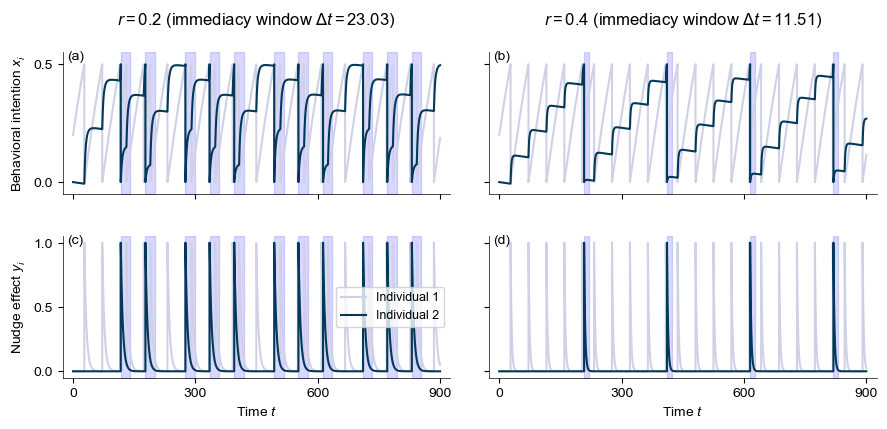

In [33]:
# PLOT FIGURE

# plot settings
c = [blues[i] for i in [3,0,2]]
xticks  = [0,300,600,900]
yticks1 = [0,0.5]
yticks2 = [0,0.5,1.0]
xlim  = [-25,925]
ylim1 = [-0.05,0.55]
ylim2 = [-0.05,1.05]

plt.figure(figsize=(16,9))

for j in range(len(rs)):

    # set recency window and events to highlight
    window = -np.log(0.01) / rs[j] # solution to Exp(-rt) == 0.01
    events = t_target[j]

    # plot behavioral intention
    ax1 = plt.subplot(4,3,4+j)
    ax1.text(0.01, 0.95, alphabet[j], transform=ax1.transAxes)
    for i in range(n):
        plt.plot(t[j], x[j][i], color=c[i], ls='-', label='Individual '+str(i+1))
    plt.ylim(ylim1)
    plt.xlim(xlim)
    for k in range(len(events)):
        plt.fill_betweenx(ylim1, events[k], events[k] + window, 
                          color='blue', alpha=0.15)

    plt.xlabel('')
    plt.title(f'$r = {rs[j]}$ (immediacy window $\\Delta t = {window:.2f}$)\n')
    ax1.set_xticks(xticks)
    ax1.set_yticks(yticks1)
    ax1.set_xticklabels([])
    if j==0:
        plt.ylabel(r'Behavioral intention $x_i$')
    else:
        ax1.set_yticklabels([])

    # plot nudge effect
    ax2 = plt.subplot(4,3,7+j) 
    ax2.text(0.01, 0.95, alphabet[2+j], transform=ax2.transAxes)
    for i in range(n):
        plt.plot(t[j], x[j][n+i], color=c[i], ls='-', label='Individual '+str(i+1))
    plt.ylim(ylim2)
    plt.xlim(xlim)
    for k in range(len(events)):
        plt.fill_betweenx(ylim2, events[k], events[k] + window, 
                          color='blue', alpha=0.15)

    plt.xlabel('')
    ax2.set_xticks(xticks)
    ax2.set_yticks(yticks2)
    if j==0:
        plt.ylabel(r'Nudge effect $y_i$')
        plt.legend(loc=7, fontsize=9)
    else:
        ax2.set_yticklabels([])
        
    plt.xlabel(r'Time $t$')

plt.subplots_adjust(hspace=0.3, wspace=0.1)

# get the current date-time string
current_datetime = datetime.now()
dts = current_datetime.strftime("%Y-%m-%d_%H.%M.%S")

# save figure with current date and time
plt.savefig('figures/figure-6_'+dts+'.pdf', bbox_inches="tight") 